In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
# Проверяем информацию о датафрейме
print(df.info())
print('Размер таблицы:', df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None
Размер таблицы: (301355, 5)


Проверяем формат столбцов

In [4]:
# Проверяем формат столбцов
print(df.dtypes)


Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [5]:
# Переводим столбец 'Дата' в формат datetime
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)
df.head()


Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
# Группируем данные по дате и считаем общее количество продаж
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()
grouped_df = grouped_df.rename(columns={'Количество': 'Количество продаж'})


Вывести несколько первых строк сгруппированных данных

In [7]:
# Смотрим несколько первых строк сгруппированных данных
print(grouped_df.head())


        Дата  Количество продаж
0 2018-01-04               3734
1 2018-01-05               3643
2 2018-01-06               3193
3 2018-01-07               3298
4 2018-01-09               4055


Нарисуйте график продаж у `grouped_df`

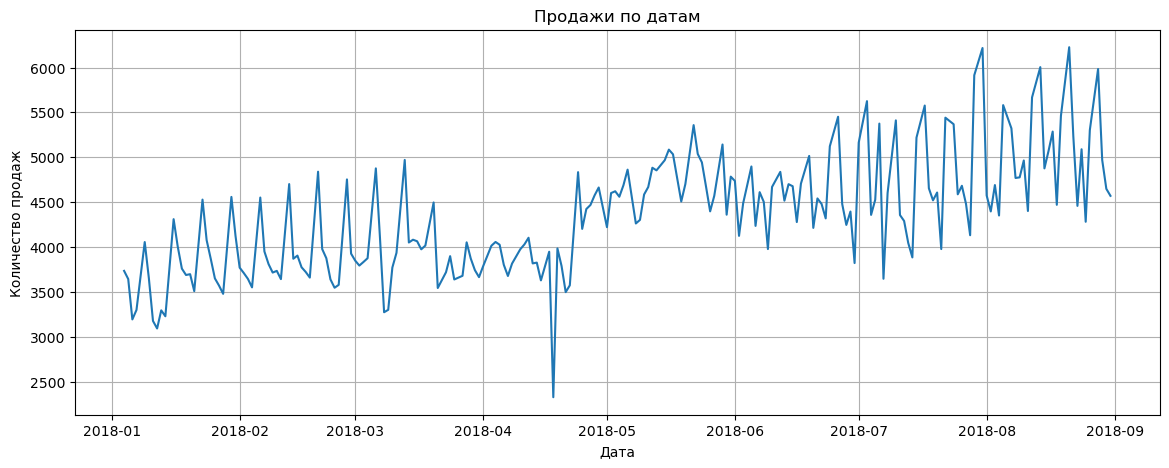

In [8]:
# График продаж по датам
plt.figure(figsize=(14, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'])
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()


Опишите что вы видите на графике. Ваша задача - максимально описать график

In [9]:
# Описание графика продаж
print('1. На графике видно, что продажи меняются неравномерно и имеют волнообразный характер.')
print('2. В начале периода продажи находятся на более низком уровне, затем в среднем постепенно растут.')
print('3. На фоне общего роста есть локальные подъемы и спады, то есть ряд не является стабильным.')
print('4. Наиболее высокие значения наблюдаются ближе к летним месяцам, особенно в июле и августе.')
print('5. Это может говорить о наличии сезонности: в теплый период продажи выше.')
print('6. Минимальные значения встречаются в начале года, а максимальные — ближе к концу рассматриваемого периода.')
print('7. В целом временной ряд показывает положительный тренд: средний уровень продаж со временем увеличивается.')


1. На графике видно, что продажи меняются неравномерно и имеют волнообразный характер.
2. В начале периода продажи находятся на более низком уровне, затем в среднем постепенно растут.
3. На фоне общего роста есть локальные подъемы и спады, то есть ряд не является стабильным.
4. Наиболее высокие значения наблюдаются ближе к летним месяцам, особенно в июле и августе.
5. Это может говорить о наличии сезонности: в теплый период продажи выше.
6. Минимальные значения встречаются в начале года, а максимальные — ближе к концу рассматриваемого периода.
7. В целом временной ряд показывает положительный тренд: средний уровень продаж со временем увеличивается.


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
# Находим строку с максимальным значением продаж в исходной таблице df
max_row = df.loc[df['Количество'].idxmax()]
print('Строка с максимальным выбросом по количеству продаж:')
display(max_row.to_frame().T)


Строка с максимальным выбросом по количеству продаж:


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28 00:00:00,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
# Ищем топовый товар по продажам по средам за июнь, июль и август у 3 складов
summer_wednesdays = df[
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.dayofweek == 2) &
    (df['Склад'].isin([1, 2, 3]))
]

top_products = (
    summer_wednesdays.groupby(['Склад', 'Номенклатура'], as_index=False)['Количество']
    .sum()
    .sort_values(['Склад', 'Количество'], ascending=[True, False])
    .groupby('Склад')
    .head(1)
)

print('Топовый товар по продажам по средам за июнь, июль, август у 3 складов:')
display(top_products)


Топовый товар по продажам по средам за июнь, июль, август у 3 складов:


,Склад,Номенклатура,Количество
1,1,product_1,2981
24,2,product_1,2887
46,3,product_1,2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

Первые строки объединенной таблицы:


,Дата,Количество продаж,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


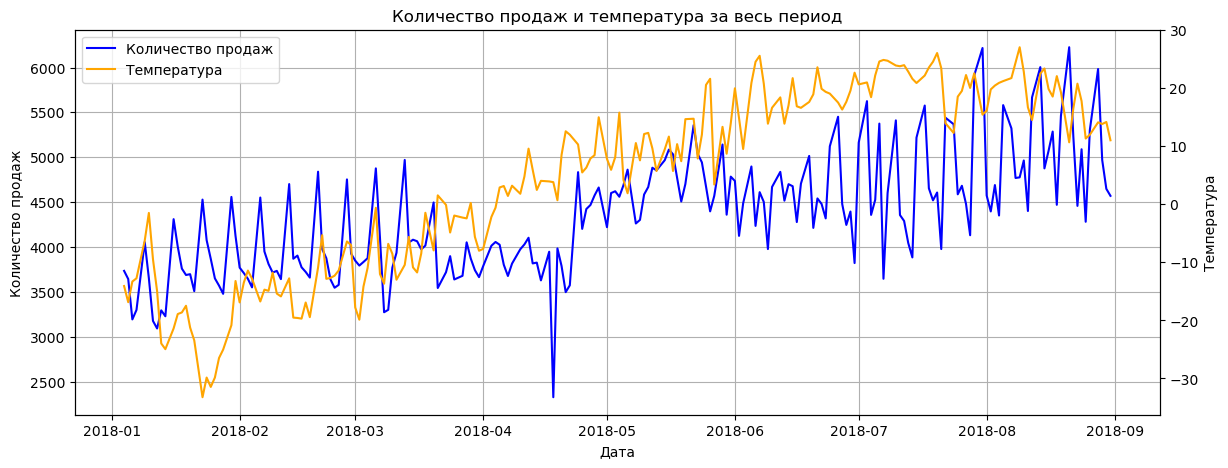

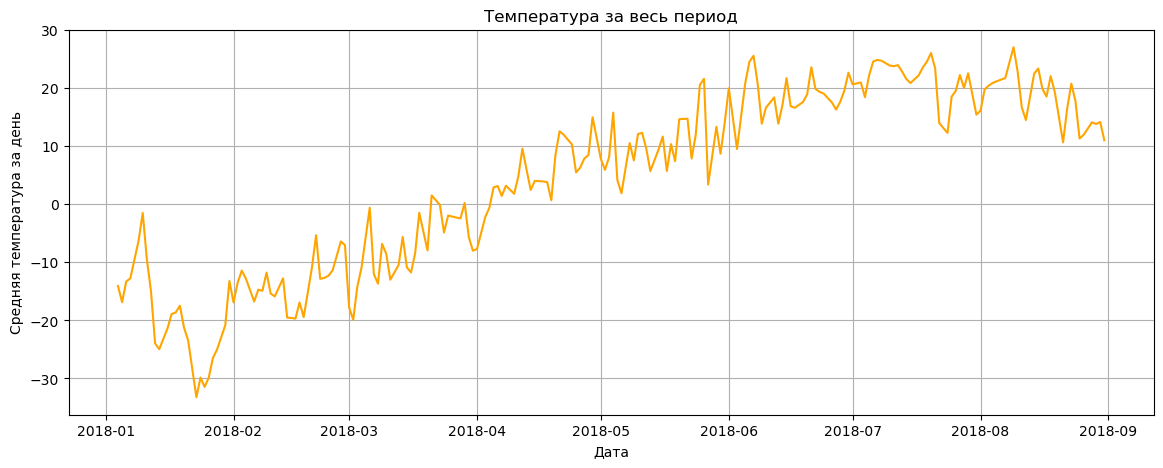

Корреляция между количеством продаж и температурой:
                   Количество продаж         T
Количество продаж           1.000000  0.600219
T                           0.600219  1.000000


In [31]:
# Читаем файл с погодой
weather = pd.read_csv('архив погоды.csv', sep=';', skiprows=6, encoding='utf-8')

# Оставляем только дату-время и температуру
weather = weather[['Местное время в Астане', 'T']].copy()

# Приводим типы
weather['Местное время в Астане'] = pd.to_datetime(
    weather['Местное время в Астане'],
    format='%d.%m.%Y %H:%M',
    errors='coerce'
)
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

# Получаем дату без времени
weather['Дата'] = weather['Местное время в Астане'].dt.normalize()

# Считаем среднюю температуру за день
weather_daily = weather.groupby('Дата', as_index=False)['T'].mean()

# Объединяем с продажами
merged_df = grouped_df.merge(weather_daily, on='Дата', how='left')

print('Первые строки объединенной таблицы:')
display(merged_df.head())

# 1. Объединенный график: продажи + температура
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    merged_df['Дата'],
    merged_df['Количество продаж'],
    label='Количество продаж',
    color='blue'
)
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    merged_df['Дата'],
    merged_df['T'],
    label='Температура',
    color='orange'
)
ax2.set_ylabel('Температура')

plt.title('Количество продаж и температура за весь период')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

# 2. Отдельный график температуры
plt.figure(figsize=(14, 5))
plt.plot(merged_df['Дата'], merged_df['T'], color='orange')
plt.title('Температура за весь период')
plt.xlabel('Дата')
plt.ylabel('Средняя температура за день')
plt.grid(True)
plt.show()

print('Корреляция между количеством продаж и температурой:')
print(merged_df[['Количество продаж', 'T']].corr())